In [2]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

<>:33: SyntaxWarning: invalid escape sequence '\P'
<>:33: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_7856\4027920584.py:33: SyntaxWarning: invalid escape sequence '\P'
  img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/opencv.png')


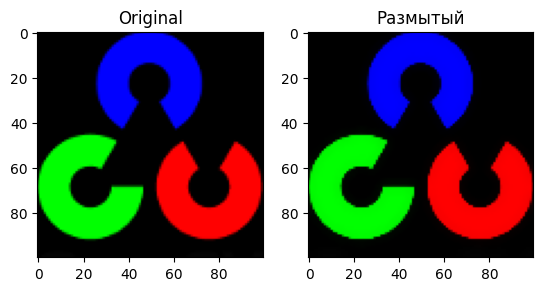

In [ ]:
"""
Сглаживание изображений

Способы:
1)cv.filter2D() - фильтрация изображений
    Операция работает следующим образом: оставьте это ядро выше пикселя, добавьте все 25 пикселей ниже этого ядра, 
    возьмите среднее значение и замените центральный пиксель новым средним значением. 
    Эта операция продолжается для всех пикселей изображения. 

2)cv.blur() или cv.boxFilter() - усреднение 
    Это делается путем свертки изображения с помощью нормализованного прямоугольного фильтра. 
    Он просто берет среднее значение всех пикселей под областью ядра и заменяет центральный элемент. 
    Это делается с помощью функции cv.blur() или cv.boxFilter(). 

3)cv.GaussianBlur() - размытие по гаусу
    В этом методе вместо коробчатого фильтра используется ядро Гаусса.
    Мы должны указать ширину и высоту ядра, которые должны быть положительными и нечетными. 
    Мы также должны указать стандартное отклонение в направлениях X и Y, sigmaX и sigmaY соответственно. 
    Если указан только sigmaX, sigmaY принимается как то же самое, что sigmaX.
    Если оба задана как нули, они вычисляются от размера ядра. 
    Размытие по Гауссу очень эффективно для удаления гауссова шума с изображения. 

4)cv.medianBlur() - срединное размытие
    Медиану всех пикселей в области ядра, и центральный элемент заменяется этим медианным значением. 
    Это очень эффективно против шума соли и перца на изображении.   
    Но при медианном размытии центральный элемент всегда заменяется на какое-то значение пикселя на изображении. 
    Это эффективно снижает уровень шума. 
    Его размер ядра должен быть положительным нечетным целым числом.

5)cv.bilateralFilter() - двусторонняя фильтрация 
    Но работа происходит медленнее по сравнению с другими фильтрами. 
    Мы уже видели, что фильтр Гаусса измеряет окрестности вокруг пикселя и находит его средневзвешенное значение по Гауссу. 
    Этот фильтр Гаусса является функцией только пространства, то есть при фильтрации учитываются соседние пиксели. 
    При этом не учитывается, имеют ли пиксели почти одинаковую интенсивность. 
    Он не учитывает, является ли пиксель краевым пикселем или нет. 
    Таким образом, он также размывает края, чего мы не хотим делать.
"""

img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/opencv.png')
assert img is not None, "file could not be read, check with os.path.exists()"
 
'''
Способ 1
kernel = np.ones((5,5),np.float32)/25
    Второй параметр отвечает за автоматическую подстановку глубины, как у исходного рисунка
dst = cv.filter2D(img,-1,kernel)
'''
'''
Способ 2
blur = cv.blur(img,(5,5))
'''
'''
Способ 3
blur = cv.GaussianBlur(img,(5,5), 0)
    Третий параметер - 'сила' размытия, где 0 - это автоматическое размытие
    К примеру, при (5,5), то 0.5 - слабое размытие, 2.0 - сильное размытие
'''
'''
Способ 4
# plt.subplot(122),plt.imshow(blur),plt.title('Размытый') #Способ 2
'''
'''
Способ 5
blur = cv.bilateralFilter(img,9,75,75)
'''
plt.subplot(121),plt.imshow(img),plt.title('Original')
# plt.xticks([]), plt.yticks([])
# plt.subplot(122),plt.imshow(dst),plt.title('Averaging') # Способ 1
plt.subplot(122),plt.imshow(blur),plt.title('Размытый') #Способ 2
# plt.xticks([]), plt.yticks([])
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\P'
<>:50: SyntaxWarning: invalid escape sequence '\P'
C:\Users\nikit\AppData\Local\Temp\ipykernel_9512\1345036143.py:50: SyntaxWarning: invalid escape sequence '\P'
  img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/photo3.jpg', cv.IMREAD_GRAYSCALE)
C:\Users\nikit\AppData\Local\Temp\ipykernel_9512\1345036143.py:75: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


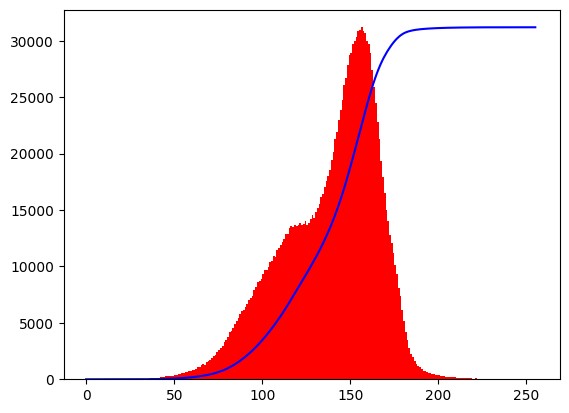

C:\Users\nikit\AppData\Local\Temp\ipykernel_9512\1345036143.py:79: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img2.flatten(),256,[0,256], color = 'r')


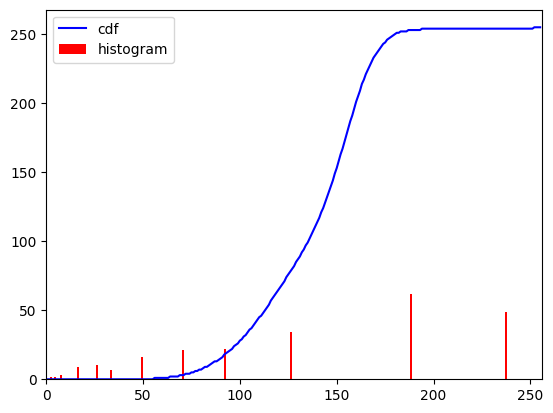

In [ ]:
"""
Гистограммы - 2: Выравнивание гистограммы

Используемые функции:
I) np.histogram(img.flatten(),256,[0,256])
    1)img.flatten() - преобразует 2D изображение в 1D массив Было: [[100, 150], [200, 50]] - Стало: [100, 150, 200, 50]
    2)256 - количество бинов (корзин) гистограммы - Для 8-битного изображения: 256 возможных значений яркости (0-255) - 
        Создает 256 интервалов
    3)[0,256] - диапазон значений - От 0 до 256 (не включая 256)

Возвращает: 
hist - массив частот: [количество_пикселей_яркостью_0, количество_пикселей_яркостью_1, ...]
bins - границы бинов: [0, 1, 2, ..., 256]

II)cdf = hist.cumsum() - Кумулятивная сумма
    Преобразует обычную гистограмму в кумулятивную (накопительную)
cdf[0] = hist[0]
cdf[1] = hist[0] + hist[1] 
cdf[2] = hist[0] + hist[1] + hist[2]
...
cdf[255] = hist[0] + hist[1] + ... + hist[255] = общее_количество_пикселей

III) cdf_normalized = cdf * float(hist.max()) / cdf.max() - нормализация CDF
    Это для того, чтобы CDF и гистограмма поместились на одном графике в одном масштабе.
hist.max() - максимальное значение в гистограмме
cdf.max() - максимальное значение в CDF (общее количество пикселей)
float(hist.max()) / cdf.max() - коэффициент масштабирования

Что по итогу:
Красная гистограмма:
    Показывает распределение яркостей
    Высокие столбцы = частые значения яркости
    Низкие столбцы = редкие значения яркости

Синяя CDF:
    Монотонно возрастающая кривая
    Показывает накопленное количество пикселей
    Крутой подъем = много пикселей в этом диапазоне
        Пологий участок = мало пикселей

Анализ контраста:
    Широкая гистограмма = высокий контраст
    Узкая гистограмма = низкий контраст

Анализ экспозиции:
    Гистограмма смещена влево = изображение темное
    Гистограмма смещена вправо = изображение светлое
    Сбалансированная гистограмма = нормальная экспозиция
"""
img = cv.imread('D:\Programming-at-SUSU\BasicOfCV\materials/photo3.jpg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
'''
Изображение 1:
Сделаем отображение гистограммы исходного изображения.
Скажи, каких больше цветов(глубина цвета) используется в этом изображении (всех пикселей).
'''
hist,bins = np.histogram(img.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

'''
Изображение 2:
Нам нужен полный спектр. 
Для этого нам нужна функция преобразования, 
    которая сопоставляет входные пиксели в более яркой области с выходными пикселями в полной области. 
Именно этим и занимается выравнивание гистограммы
'''
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf_2 = np.ma.filled(cdf_m,0).astype('uint8')
img2 = cdf[img]

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.show()

plt.plot(cdf_2, color = 'b')
plt.hist(img2.flatten(),256,[0,256], color = 'r')

plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left') #Маленькая рамочка с обозначением
plt.show()